In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_unified/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified/bias_values_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified/resampsamp_{config_str}.npy")

In [4]:
print(np.shape(resampled_samples))

(4, 999990, 10)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[-296.09611166 -365.5091279  -365.20443342 ...   70.73218282
    70.71802822   70.12332719]
 [ 323.92852614  187.18230558  -84.0555297  ...  110.14649732
   110.30493655  111.1639567 ]
 [1249.35143561 -104.75761861 -181.8927822  ...   71.809729
    71.86125644   73.1586013 ]
 [-356.90928756 -397.00670577 -397.72581384 ...   69.932941
    69.269695     69.29875866]]


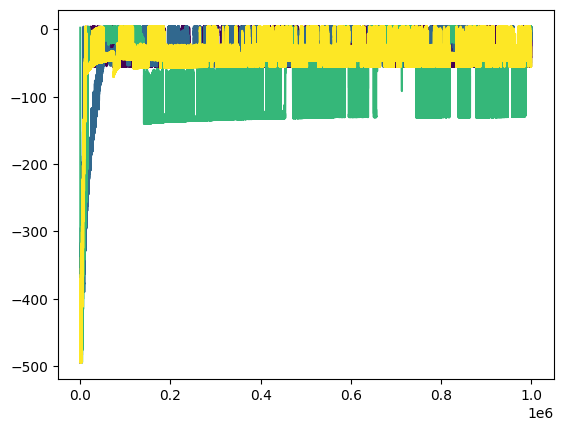

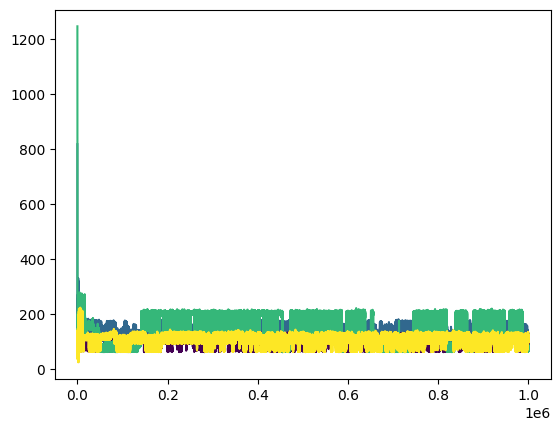

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


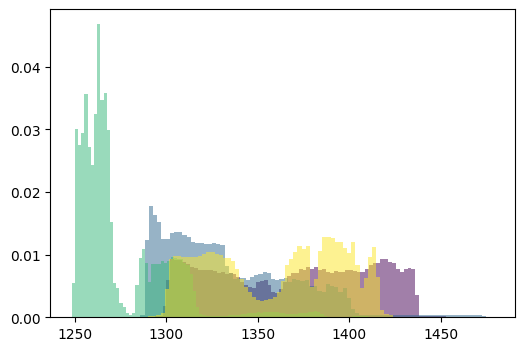

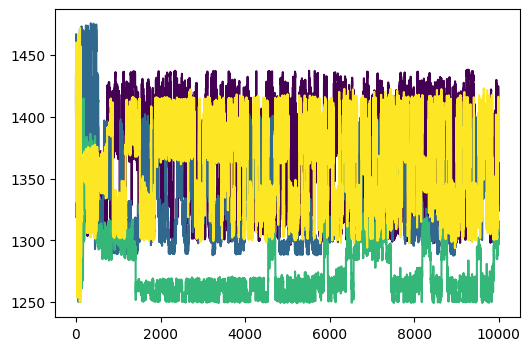

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, ::100], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::1000,:]

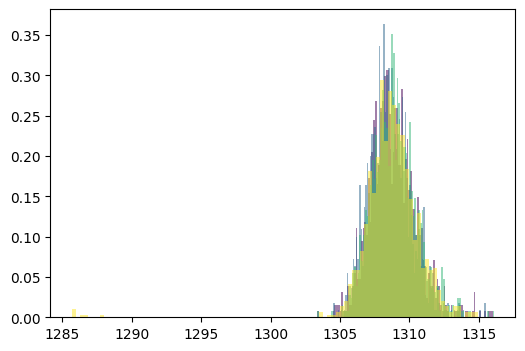

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

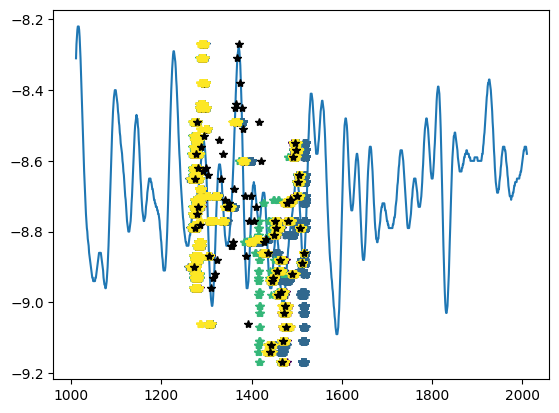

In [11]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [12]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]   7.61  4.30    0.01    11.58       2.09     1.15      7.19     29.74   
x[1]   8.85  4.85    0.09    13.99       2.26     1.15      7.20     29.95   
x[2]   6.12  3.12    0.33    10.92       1.19     0.37      7.69     30.72   
x[3]  15.85  6.06    9.27    27.25       2.81     1.59      7.20     27.40   
x[4]  67.20  5.89   61.25    79.07       2.75     1.61      8.10     30.85   
x[5]   8.93  1.45    6.31    11.60       0.02     0.02   3940.92   3827.28   
x[6]   5.04  1.49    2.22     7.93       0.02     0.02   3778.16   3450.03   
x[7]   1.21  0.88    0.01     2.79       0.01     0.01   3833.44   3974.80   
x[8]   0.86  0.66    0.01     2.07       0.01     0.01   3845.76   3717.87   
x[9]   2.44  1.77    0.01     5.69       0.03     0.02   4017.78   3638.26   

      r_hat  
x[0]   1.53  
x[1]   1.53  
x[2]   1.47  
x[3]   1.53  
x[4]   1.50  
x[5]   1.00  
x[6]   1.00  
x[7]   1.00  
x[8]   1.00  
x

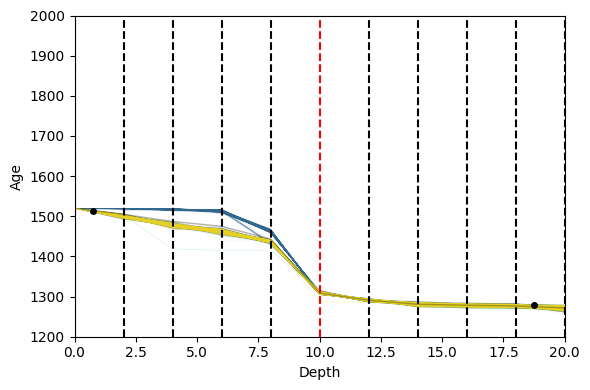

In [13]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()